# NEUSEG npz check

Load one `*.npz` from a batch run and check the GM/WM segmentation
against the slide thumbnail.

In [10]:
import json

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

NPZ = ("/home/hsroh/Research/bvFTD_Eval_cohort/chead_batch_results/OFC/GFAP/2004-158-29F_L_OFC_GFAP_4K_02-08-22_EX.npz")

# NEUSEG's own palette (neuseg/gmwm_segmentation.py), so this matches the
# debug figures the pipeline writes.
GMWM_C, GMCSF_C = "#00c800", "#dc00ff"
GM_FILL_C, WM_FILL_C, FILL_ALPHA = "#d9b3e6", "#bff2bf", 0.25

In [11]:
# gmwm_contours is a JSON string: {"shape": [h, w], "gm_wm": [...], "gm_csf": [...]},
# each boundary a list of [[x, y], ...] rings in thumbnail pixels.
with np.load(NPZ, allow_pickle=True) as z:
    thumbnail = z["thumbnail"]
    gm_mask, wm_mask = z["gm_mask"], z["wm_mask"]
    contours = json.loads(str(z["gmwm_contours"]))

print(f"thumbnail {thumbnail.shape}")
print(f"GM {gm_mask.sum():,} px, WM {wm_mask.sum():,} px")
print({key: f"{len(contours[key])} rings" for key in ("gm_wm", "gm_csf")})

thumbnail (2738, 3112, 3)
GM 2,758,164 px, WM 1,891,791 px
{'gm_wm': '1 rings', 'gm_csf': '2 rings'}


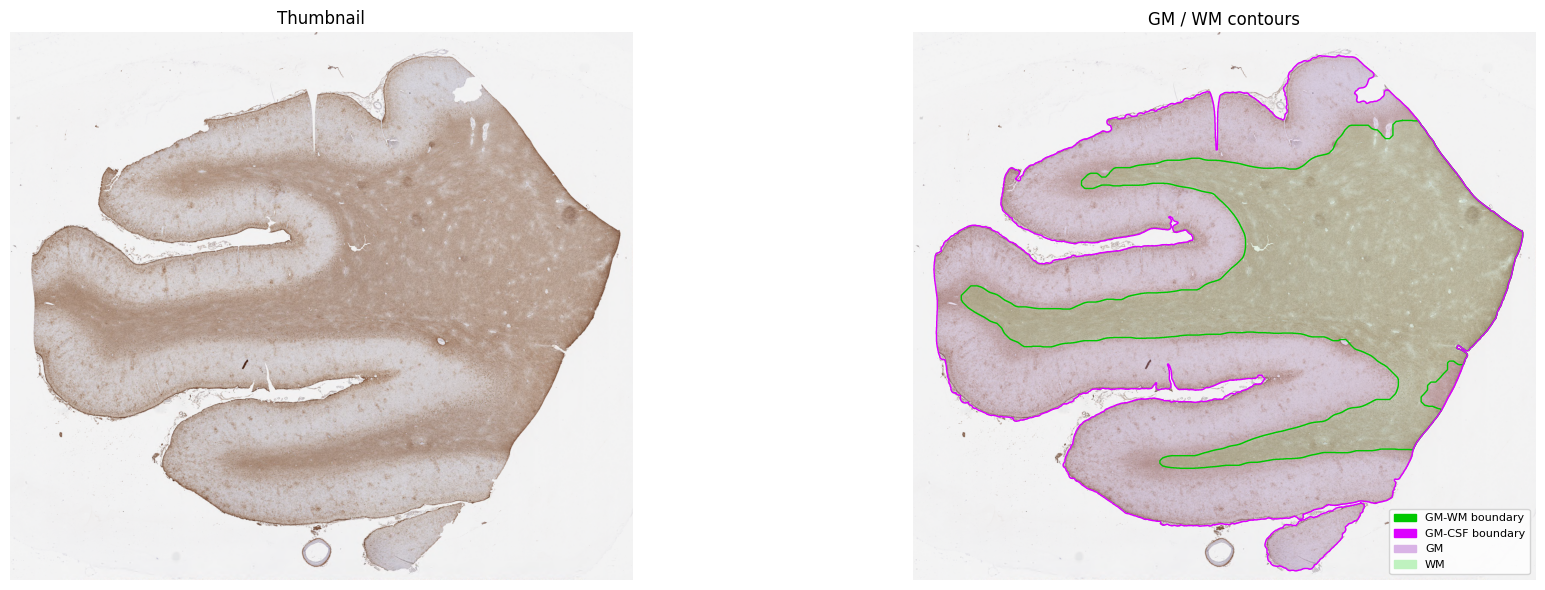

In [12]:
def tint(mask, color):
    """RGBA layer, `color` where the mask is True and transparent elsewhere."""
    layer = np.zeros((*mask.shape, 4))
    layer[mask] = to_rgba(color, FILL_ALPHA)
    return layer


fig, (left, right) = plt.subplots(1, 2, figsize=(20, 6))

left.imshow(thumbnail)
left.set_title("Thumbnail")

right.imshow(thumbnail)
right.imshow(tint(gm_mask, GM_FILL_C), interpolation="nearest")
right.imshow(tint(wm_mask, WM_FILL_C), interpolation="nearest")

# Close each ring by repeating its first point, then draw it in thumbnail pixels.
for key, color in (("gm_wm", GMWM_C), ("gm_csf", GMCSF_C)):
    for ring in contours[key]:
        xy = np.asarray(ring + ring[:1])
        right.plot(xy[:, 0], xy[:, 1], color=color, linewidth=1.0)

right.set_title("GM / WM contours")
right.legend(handles=[Patch(color=GMWM_C, label="GM-WM boundary"),
                      Patch(color=GMCSF_C, label="GM-CSF boundary"),
                      Patch(color=GM_FILL_C, label="GM"),
                      Patch(color=WM_FILL_C, label="WM")],
             loc="lower right", fontsize=8)

for ax in (left, right):
    ax.axis("off")
fig.tight_layout()
plt.show()